# Wash Trading · Part 1 · v2 Mechanism Results

v2 builds three things on top of v1 (active co-arrival + one directed edge per event). **The v1 package is frozen and untouched.**

1. **The number of wallets is a first-class parameter**: a **2-wallet** group (A↔B round trips) now exists next to the
   existing **3-wallet** triangle (A→B→C→A). n=2 is the smallest wash structure and the hardest one for a
   counterparty-graph detector (a single reciprocal edge), so Part 2 needs it as a separate condition.
2. **The time gap between the two legs becomes a parameter, `wash_gap`** (in timesteps). v1 hard-codes gap=0 (both wallets
   act in the **same** timestep and trade against each other in the same batch clear); v2 posts the first leg at t and the
   second at t+gap. With gap>0 the first leg is **exposed** in the book, and any ZI that arrives in between can take it.
   This is the "exposed order" mechanism mentioned in the v1 notes, and **gap is the real spillover knob** (`wash_eps` is not).
   `wash_gap=0` is exactly equivalent to v1 (checked event by event and price by price in the smoke test).
3. **LOB data is persisted**: every timestep that clears records a book snapshot (quotes and depth before and after the
   clear, clear price, volume, wash flags), plus the top-K levels per side. `analysis.save_run` writes the LOB, the trade
   tape, the wash events, the per-leg fills and a meta file as CSV/JSON.

> Data sources: `matched_orders` (trade tape; positions are rebuilt from it after the fact) + `controller.event_log` /
> `fill_log` (ground-truth label stream) + `sim.lob` (book snapshots). Nothing in `marketsim/` is modified.


In [1]:
import os, sys, json, time

def _find_root(start):
    d = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(d, "marketsim")) and os.path.isdir(os.path.join(d, "capstone codes")):
            return d
        p = os.path.dirname(d)
        if p == d:
            return None
        d = p

ROOT = _find_root(os.getcwd())
assert ROOT, "repo root not found (need marketsim/ + 'capstone codes/')"
for p in (ROOT, os.path.join(ROOT, "capstone codes")):
    if p not in sys.path:
        sys.path.insert(0, p)

import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from washtrade.v2 import WashTradingSimulator
from washtrade.v2 import analysis as A

pd.set_option("display.width", 160)
DATA_DIR = os.path.join(ROOT, "capstone codes", "washtrade", "v2", "data")

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

def run(composition, seed=0, lam_wash=None, wash_eps=0.0, wash_gap=0,
        wash_first_leg="random", sim_time=2000, record_lob=True):
    """Single entry point for all experiments. ZI background lam=5e-3, T=2000 (Table 3); the wash event rate lam_wash is independent."""
    seed_all(seed)
    sim = WashTradingSimulator(composition, sim_time=sim_time, lam=5e-3,
                               lam_wash=lam_wash, wash_eps=wash_eps, wash_gap=wash_gap,
                               wash_first_leg=wash_first_leg, wash_seed=seed,
                               record_lob=record_lob)
    sim.run()
    return sim

LAM_WASH = 0.05   # one event every ~20 steps on average -> roughly 50-100 events at T=2000
print("repo root:", os.path.basename(ROOT))

repo root: wash-trading-capstone


## A. Three baseline conditions (gap = 0)

- **All-ZI negative control**: no wash wallets, the controller idles (0 events); measures the false-positive baseline.
- **2 wallets**: A↔B, one full cycle every 2 events.
- **3 wallets**: A→B→C→A, one full cycle every 3 events (= the v1 condition).


In [2]:
ctrl = run({"ZI": 14}, seed=0)
w2   = run({"ZI": 13, "WashTrader": 2}, seed=0, lam_wash=LAM_WASH, wash_gap=0)
w3   = run({"ZI": 13, "WashTrader": 3}, seed=0, lam_wash=LAM_WASH, wash_gap=0)

base = pd.DataFrame({"all-ZI control": A.summarize(ctrl),
                     "2 wallets (gap=0)": A.summarize(w2),
                     "3 wallets (gap=0)": A.summarize(w3)}).T
base

,n_wallets,wash_gap,first_leg,n_events,n_events_closed,n_self_trades,self_trade_rate,n_intercepted,intercept_rate,wash_qty_posted,wash_qty_filled,leg_fill_rate,total_trade_legs,wash_trade_legs,wash_leg_share,total_volume,wash_volume,wash_volume_share,wash_group_final_net
all-ZI control,0,0,random,0,0,0,NaN,0,NaN,0.0,0.0,NaN,30,0,0.0,15.0,0.0,0.0,0
2 wallets (gap=0),2,0,random,89,89,89,1.0,0,0.0,178.0,178.0,1.0,198,178,0.89899,99.0,89.0,0.89899,0
3 wallets (gap=0),3,0,random,89,89,89,1.0,0,0.0,178.0,178.0,1.0,198,178,0.89899,99.0,89.0,0.89899,0


### A1. Equivalence with v1

With `wash_gap=0` the first and second legs of v2 land in the same timestep and the same batch clear, and the order-id
allocation order and event-queue insertion order also match v1, so **with the same seed v2 should reproduce v1 event by
event**. This guarantees that v2 does not silently change any v1 conclusion.


In [3]:
from washtrade.v1 import WashTradingSimulator as V1Sim

seed_all(0)
v1 = V1Sim({"ZI": 13, "WashTrader": 3}, sim_time=2000, lam=5e-3,
           lam_wash=LAM_WASH, wash_eps=0.0, wash_seed=0)
v1.run()

e1 = pd.DataFrame(v1.controller.event_log)
e2 = A.event_log_df(w3)
same = dict(
    n_events        = (len(e1), len(e2)),
    n_self_trades   = (int(e1.self_trade.sum()), int(e2.self_trade.sum())),
    trade_legs      = (len(v1.markets[0].matched_orders), len(w3.markets[0].matched_orders)),
    wallet_positions= ([v1.agents[i].position for i in v1.wash_wallet_ids],
                       [w3.agents[i].position for i in w3.wash_wallet_ids]),
)
edges_same  = (e1[["seller", "buyer"]].values == e2[["seller", "buyer"]].values).all()
prices_same = np.allclose(e1["anchor"].values, e2["anchor"].values)
times_same  = (e1["t"].values == e2["open_time"].values).all()

for k, (a, b) in same.items():
    print(f"  {k:16s} v1={a}   v2={b}   {'OK' if a == b else 'MISMATCH'}")
print(f"  same edge per event : {bool(edges_same)} | same anchor price per event : {bool(prices_same)} | same time per event : {bool(times_same)}")

  n_events         v1=89   v2=89   OK
  n_self_trades    v1=89   v2=89   OK
  trade_legs       v1=198   v2=198   OK
  wallet_positions v1=[-1, 0, 1]   v2=[-1, 0, 1]   OK
  same edge per event : True | same anchor price per event : True | same time per event : True


## B. 2 wallets vs 3 wallets: the rotation structure

A single wallet swings between ±q; n wallets rotate out of phase and the group's net position hugs 0.
n=2 is the reciprocal "you sell to me, I sell back to you" edge; n=3 is a triangular rotation. For the Part 2
counterparty graph the former has a single edge and the latter a directed cycle, so they are not equally hard to detect.


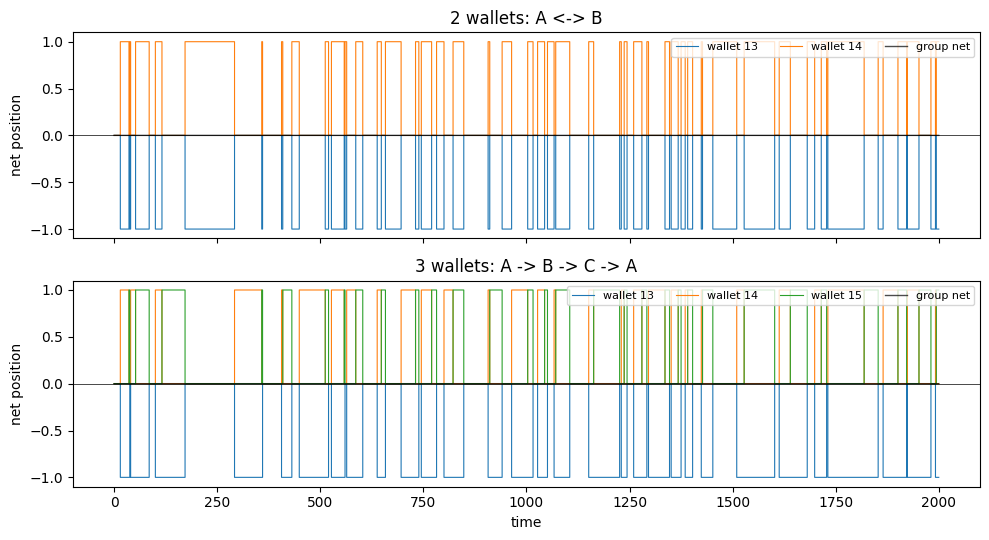

2 wallets: completed 44 cycles, boundary net position range [0, 0] (target is always 0)
3 wallets: completed 29 cycles, boundary net position range [0, 0] (target is always 0)


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for ax, sim, name in zip(axes, (w2, w3), ("2 wallets: A <-> B", "3 wallets: A -> B -> C -> A")):
    ts = A.position_timeseries(sim)
    for aid in ts.columns:
        ax.step(ts.index, ts[aid], lw=0.8, where="post", label=f"wallet {aid}")
    ax.plot(ts.index, ts.sum(axis=1), color="k", lw=1.0, alpha=.7, label="group net")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(name); ax.set_ylabel("net position")
    ax.legend(loc="upper right", ncol=4, fontsize=8)
axes[-1].set_xlabel("time")
plt.tight_layout(); plt.show()

for sim, name in ((w2, "2 wallets"), (w3, "3 wallets")):
    nets = A.cycle_boundary_nets(sim)
    print(f"{name}: completed {len(nets)} cycles, boundary net position range [{min(nets)}, {max(nets)}] (target is always 0)")

## C. The core experiment: scanning the time gap

`wash_gap` is the knob introduced in v2. At gap=0 both legs trade in the same batch clear and nobody can get in between;
at gap>0 the first leg sits **exposed** in the book for `gap` steps, and every ZI arrival in that window triggers a clear, so:

- **self-trade rate ↓** (the pair is broken up),
- **intercept rate ↑** (the first leg is taken by a ZI = spillover),
- **leg fill rate ↓** (the second leg sometimes rests without trading),
- the wash group's net position no longer returns strictly to zero: this is the **inventory risk** the wash trader pays
  for not being synchronized.

Below: a full scan over gap ∈ {0,1,2,5,10,20,50}, wallets ∈ {2,3}, seeds ∈ {0,1,2}.


In [5]:
GAPS  = [0, 1, 2, 5, 10, 20, 50]
SEEDS = [0, 1, 2]
t0 = time.time()

rows = []
for n_w in (2, 3):
    for gap in GAPS:
        for seed in SEEDS:
            sim = run({"ZI": 13, "WashTrader": n_w}, seed=seed,
                      lam_wash=LAM_WASH, wash_gap=gap, record_lob=True)
            s = A.summarize(sim); q = A.market_quality(sim)
            nets = A.cycle_boundary_nets(sim)
            rows.append(dict(n_wallets=n_w, gap=gap, seed=seed,
                             n_events=s["n_events"],
                             self_trade_rate=s["self_trade_rate"],
                             intercept_rate=s["intercept_rate"],
                             leg_fill_rate=s["leg_fill_rate"],
                             wash_volume_share=s["wash_volume_share"],
                             group_final_net=s["wash_group_final_net"],
                             max_abs_cycle_net=max(abs(x) for x in nets) if nets else 0,
                             mean_spread=q.get("mean_spread", float("nan")),
                             mid_vs_fundamental=q.get("mean_mid_vs_fundamental", float("nan"))))
scan = pd.DataFrame(rows)
print(f"{len(scan)} simulations, {time.time() - t0:.0f}s elapsed")

agg = (scan.groupby(["n_wallets", "gap"])
            .agg(n_events=("n_events", "mean"),
                 self_trade_rate=("self_trade_rate", "mean"),
                 intercept_rate=("intercept_rate", "mean"),
                 leg_fill_rate=("leg_fill_rate", "mean"),
                 wash_volume_share=("wash_volume_share", "mean"),
                 max_abs_cycle_net=("max_abs_cycle_net", "max"))
            .round(3))
agg

42 simulations, 2s elapsed


n_events  self_trade_rate  intercept_rate  leg_fill_rate  wash_volume_share  max_abs_cycle_net
n_wallets gap                                                                                                
2         0      92.667            0.987           0.000          0.993              0.884                  2
          1      87.000            0.977           0.008          0.990              0.865                  2
          2      83.000            0.979           0.008          0.990              0.855                  1
          5      73.333            0.926           0.051          0.972              0.839                  3
          10     63.667            0.904           0.080          0.957              0.829                  4
          20     47.333            0.755           0.218          0.899              0.763                  8
          50     28.000            0.546           0.370          0.781              0.588                  5
3         0      92.667            0.987           0.000          0.995              0.883                  2
          1      87.000            0.977           0.008          0.990              0.865                  2
          2      83.000            0.979           0.008          0.990              0.855                  1
          5      73.333            0.931           0.051          0.977              0.839                  2
          10     63.667            0.898           0.086          0.955              0.823                  4
          20     47.333            0.755           0.218          0.902              0.761                  8
          50     28.000            0.534           0.382          0.781              0.582                  5

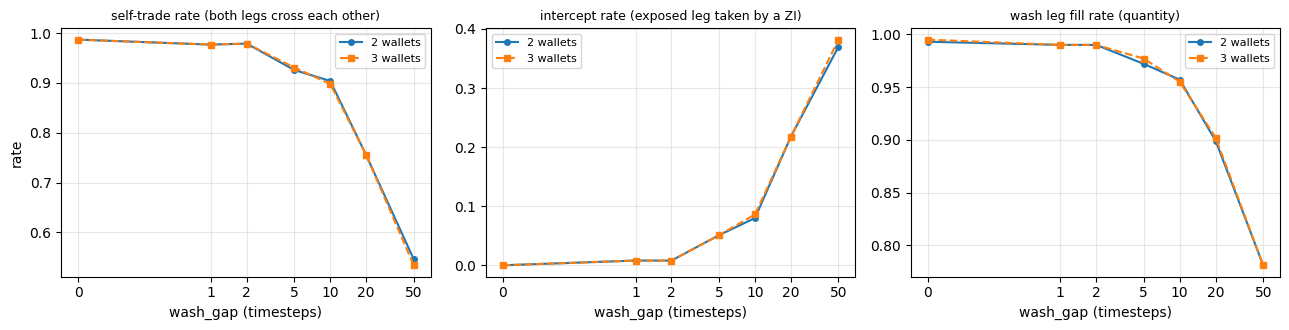

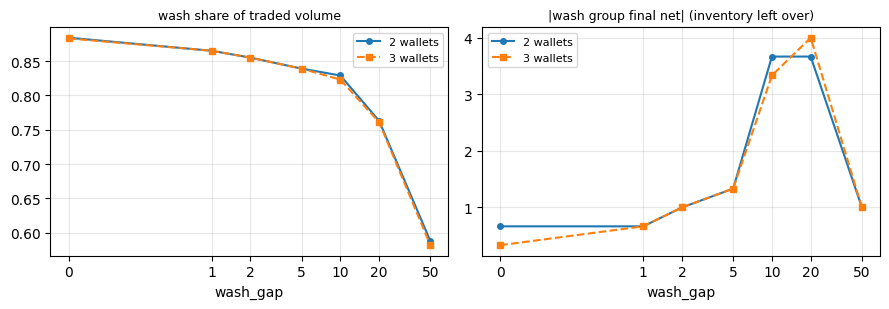

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
metrics = [("self_trade_rate", "self-trade rate (both legs cross each other)"),
           ("intercept_rate",  "intercept rate (exposed leg taken by a ZI)"),
           ("leg_fill_rate",   "wash leg fill rate (quantity)")]
for ax, (m, title) in zip(axes, metrics):
    for n_w, mk in ((2, "o-"), (3, "s--")):
        sub = agg.loc[n_w]
        ax.plot(sub.index, sub[m], mk, ms=4, label=f"{n_w} wallets")
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xticks(GAPS); ax.set_xticklabels(GAPS)
    ax.set_xlabel("wash_gap (timesteps)"); ax.set_title(title, fontsize=9)
    ax.grid(alpha=.3); ax.legend(fontsize=8)
axes[0].set_ylabel("rate")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for n_w, mk in ((2, "o-"), (3, "s--")):
    axes[0].plot(agg.loc[n_w].index, agg.loc[n_w]["wash_volume_share"], mk, ms=4, label=f"{n_w} wallets")
    sub = scan[scan.n_wallets == n_w].groupby("gap")["group_final_net"].apply(lambda s: s.abs().mean())
    axes[1].plot(sub.index, sub.values, mk, ms=4, label=f"{n_w} wallets")
for ax, t in zip(axes, ["wash share of traded volume", "|wash group final net| (inventory left over)"]):
    ax.set_xscale("symlog", linthresh=1); ax.set_xticks(GAPS); ax.set_xticklabels(GAPS)
    ax.set_xlabel("wash_gap"); ax.set_title(t, fontsize=9); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## D. Mechanism details of the gap: what happens to the exposed leg

An event with gap>0 has one of three outcomes:

| Outcome | Criterion | Meaning |
|---|---|---|
| Clean self-trade | `self_trade=True` | both legs trade against each other in the same batch clear at t+gap (same as gap=0) |
| Intercepted (spillover) | `intercepted=True` | the first leg is taken by a ZI between t and t+gap; the second leg is still sent and may trade with the market or rest unfilled |
| Left unfilled | `unfilled>0` | the two legs together did not move the full 2q, so the wallet keeps a net position |

Below, one run at gap=20: how long the first leg waits in the book before it trades, and whether it stays at the top of
the book during its exposure.


clean self-trade    34
intercepted         11
left unfilled       13
total events        47 



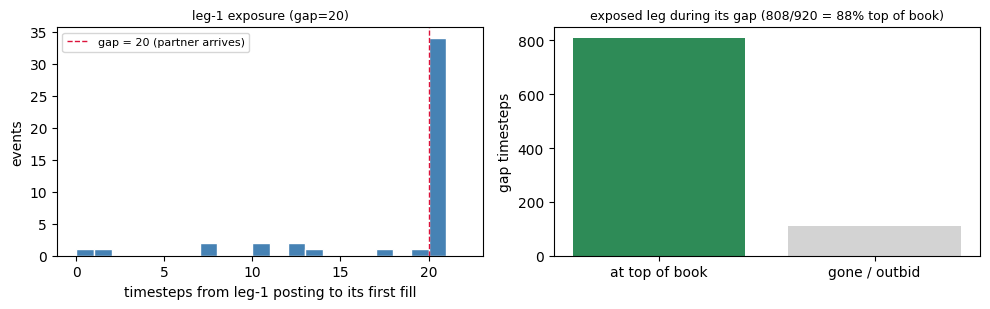

Sample of intercepted events:


,event_idx,open_time,close_time,first_leg,seller,buyer,seller_filled_pre,buyer_filled_pre,seller_filled,buyer_filled,self_trade,intercepted,unfilled
0,0,14,34,BUY,13,14,0.0,1.0,0.0,1.0,False,True,1.0
2,2,77,97,BUY,15,13,0.0,1.0,0.0,1.0,False,True,1.0
5,5,184,204,BUY,15,13,0.0,1.0,0.0,1.0,False,True,1.0
6,6,219,239,SELL,13,14,1.0,0.0,1.0,0.0,False,True,1.0
8,8,331,351,BUY,15,13,0.0,1.0,0.0,1.0,False,True,1.0
12,12,645,665,SELL,13,14,1.0,0.0,1.0,0.0,False,True,1.0
15,15,748,768,SELL,13,14,1.0,0.0,1.0,0.0,False,True,1.0
21,21,983,1003,SELL,13,14,1.0,0.0,1.0,0.0,False,True,1.0


In [7]:
g20 = run({"ZI": 13, "WashTrader": 3}, seed=0, lam_wash=LAM_WASH, wash_gap=20)
tim = A.event_timing_df(g20)
ev20 = A.event_log_df(g20)

outcome = pd.Series({
    "clean self-trade": int(ev20.self_trade.sum()),
    "intercepted":      int(ev20.intercepted.sum()),
    "left unfilled":    int((ev20.unfilled > 0).sum()),
    "total events":     len(ev20),
})
print(outcome.to_string(), "\n")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(tim["leg1_exposure"].dropna(), bins=range(0, 23), color="steelblue", edgecolor="w")
axes[0].axvline(20, color="crimson", ls="--", lw=1, label="gap = 20 (partner arrives)")
axes[0].set_xlabel("timesteps from leg-1 posting to its first fill")
axes[0].set_ylabel("events"); axes[0].set_title("leg-1 exposure (gap=20)", fontsize=9)
axes[0].legend(fontsize=8)

# is the first leg at the best price of the book during its exposure?
lob = A.lob_dense(g20)
hit = tot = 0
for _, e in ev20.iterrows():
    if not e["closed"]:
        continue
    px  = e["sell_px"] if e["first_leg"] == "SELL" else e["buy_px"]
    col = "best_ask"   if e["first_leg"] == "SELL" else "best_bid"
    for t in range(int(e["open_time"]), int(e["close_time"])):
        v = lob.loc[t, col]; tot += 1
        hit += int(np.isfinite(v) and abs(v - px) < 1e-6)
axes[1].bar(["at top of book", "gone / outbid"], [hit, tot - hit], color=["seagreen", "lightgray"])
axes[1].set_title(f"exposed leg during its gap ({hit}/{tot} = {100*hit/tot:.0f}% top of book)", fontsize=9)
axes[1].set_ylabel("gap timesteps")
plt.tight_layout(); plt.show()

cols = ["event_idx", "open_time", "close_time", "first_leg", "seller", "buyer",
        "seller_filled_pre", "buyer_filled_pre", "seller_filled", "buyer_filled",
        "self_trade", "intercepted", "unfilled"]
print("Sample of intercepted events:")
ev20[ev20.intercepted][cols].head(8)

## E. LOB data

One row is recorded for every timestep that clears: the book **before** the clear (`*_pre`), the book after the clear,
the clear price, the volume, how many legs belong to wash wallets (`wash_legs`), and which phase of a wash event this
step is (`wash_phase` ∈ open/close/both). The top-5 levels per side are stored separately as a long table.

The book only changes in timesteps where `market.step()` is called (upstream only steps when there is an arrival or a wash
leg), so sampling per event is **lossless**; `A.lob_dense()` forward-fills to a per-timestep series.

> The recorder is **read-only**: it never calls `get_fundamental_value()` (the fundamental is generated lazily, and one
> extra query would change the random path). It only reads already-generated cached values, and when none is available it
> reuses the previous one and sets the `fund_stale` flag.


In [8]:
g5 = run({"ZI": 13, "WashTrader": 3}, seed=0, lam_wash=LAM_WASH, wash_gap=5)
lob5 = A.lob_df(g5)
print("LOB snapshot table shape:", lob5.shape)
print(f"{100 * lob5.fund_stale.mean():.1f}% of rows have fund_stale=True (0% at gap=0): "
      f"in those timesteps only the second wash leg is present and no ZI arrived, so nobody queried the fundamental value; "
      f"the recorder does not trigger a fresh lazy draw just to fill that cell (it would change the random path) "
      f"and reuses the last generated value.")
lob5.head(6)

LOB snapshot table shape: (250, 25)
25.6% of rows have fund_stale=True (0% at gap=0): in those timesteps only the second wash leg is present and no ZI arrived, so nobody queried the fundamental value; the recorder does not trigger a fresh lazy draw just to fill that cell (it would change the random path) and reuses the last generated value.


,time,best_bid_pre,best_ask_pre,mid_pre,spread_pre,bid_depth_pre,ask_depth_pre,n_bid_orders_pre,n_ask_orders_pre,best_bid,...,n_bid_orders,n_ask_orders,fundamental,fund_stale,clear_price,n_matched_legs,volume,wash_legs,wash_phase,wash_event_idx
0,14,NaN,NaN,NaN,NaN,0.0,0.0,0,0,104175.058973,...,1,0,104175.058973,False,NaN,0,0.0,0,open,0
1,19,104175.058973,NaN,NaN,NaN,1.0,0.0,1,0,NaN,...,0,0,104175.058973,True,104175.058973,2,1.0,2,close,0
2,21,NaN,NaN,NaN,NaN,0.0,0.0,0,0,NaN,...,0,1,103769.534129,False,NaN,0,0.0,0,,-1
3,40,NaN,100326.763786,NaN,NaN,0.0,1.0,0,1,NaN,...,0,2,106538.441011,False,NaN,0,0.0,0,open,1
4,45,NaN,100325.763786,NaN,NaN,0.0,2.0,0,2,NaN,...,0,1,106538.441011,True,100325.763786,2,1.0,2,close,1
5,47,NaN,100326.763786,NaN,NaN,0.0,1.0,0,1,100325.763786,...,1,1,106489.649583,False,NaN,0,0.0,0,open,2


top-5 levels long table shape: (2044, 6)


,time,side,level,price,qty,n_orders
1020,1128,bid,0,100013.482724,1.0,1
1021,1128,bid,1,99959.609492,1.0,1
1022,1128,bid,2,99852.754780,1.0,1
1023,1128,bid,3,99658.072079,1.0,1
1024,1128,bid,4,99519.282592,1.0,1
1025,1128,ask,0,100588.690162,1.0,1
1026,1128,ask,1,100607.704546,1.0,1
1027,1128,ask,2,100715.200926,1.0,1
1028,1128,ask,3,100965.601514,1.0,1


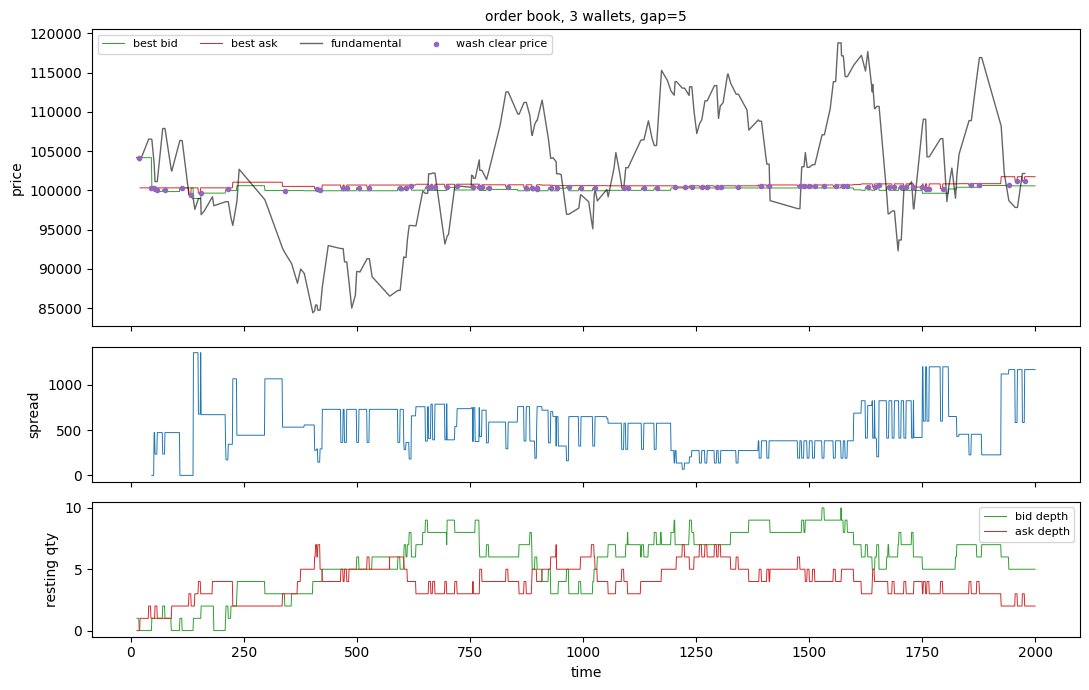

n_clears                    250.00
mean_spread                 503.25
median_spread               414.53
mean_bid_depth                5.71
mean_ask_depth                4.07
n_steps_with_trade           84.00
mean_mid_vs_fundamental   -2324.93


In [9]:
lv = A.lob_levels_df(g5)
print("top-5 levels long table shape:", lv.shape)
display(lv[lv.time == lv.time.iloc[len(lv)//2]])

dense = A.lob_dense(g5)
mask = lob5["wash_legs"] > 0

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True,
                         gridspec_kw=dict(height_ratios=[2.2, 1, 1]))
ax = axes[0]
ax.plot(dense.index, dense["best_bid"], lw=.7, color="tab:green", label="best bid")
ax.plot(dense.index, dense["best_ask"], lw=.7, color="tab:red", label="best ask")
ax.plot(lob5["time"], lob5["fundamental"], lw=1.0, color="k", alpha=.6, label="fundamental")
ax.scatter(lob5.loc[mask, "time"], lob5.loc[mask, "clear_price"], s=9, color="tab:purple",
           zorder=3, label="wash clear price")
ax.set_ylabel("price"); ax.legend(fontsize=8, ncol=4); ax.set_title("order book, 3 wallets, gap=5", fontsize=10)

axes[1].plot(dense.index, dense["spread"], lw=.7, color="tab:blue")
axes[1].set_ylabel("spread")
axes[2].plot(dense.index, dense["bid_depth"], lw=.7, color="tab:green", label="bid depth")
axes[2].plot(dense.index, dense["ask_depth"], lw=.7, color="tab:red", label="ask depth")
axes[2].set_ylabel("resting qty"); axes[2].set_xlabel("time"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(pd.Series(A.market_quality(g5)).round(2).to_string())

### E1. Persisting a run

`A.save_run(sim, outdir, tag)` writes 7 files at once:

| File | Content |
|---|---|
| `*_lob.csv` | one book snapshot per clear (quotes before/after, depth, clear price, volume, wash flags) |
| `*_lob_levels.csv` | top-5 levels per side per clear (long format) |
| `*_trades.csv` | trade tape (one row per leg, includes `is_wash`) |
| `*_wash_events.csv` | wash events (intent + realized fills + self_trade/intercepted/unfilled) |
| `*_wash_fills.csv` | per-fill records of wash orders (order_id level, including "late legs" that fill after the event ended) |
| `*_wash_orders.csv` | how much of each wash order eventually filled / stayed unfilled |
| `*_meta.json` | all parameters, summary metrics, cycle-boundary net positions, final positions |


In [10]:
saved = {}
for name, sim in [("w2_gap0", w2), ("w3_gap0", w3),
                  ("w3_gap5", g5), ("w3_gap20", g20), ("zionly", ctrl)]:
    saved[name] = A.save_run(sim, os.path.join(DATA_DIR, "results_v2"), tag=name)

for name, paths in saved.items():
    tot = sum(os.path.getsize(p) for p in paths.values())
    print(f"  {name:9s} -> {len(paths)} files, {tot/1024:6.1f} KB")
print("\ndirectory:", os.path.relpath(os.path.join(DATA_DIR, "results_v2"), ROOT))
print("\nmeta.json example:")
print(json.dumps(json.load(open(saved['w3_gap5']['meta'], encoding='utf-8'))['summary'], indent=2)[:700])

  w2_gap0   -> 7 files,  156.9 KB
  w3_gap0   -> 7 files,  156.8 KB
  w3_gap5   -> 7 files,  169.2 KB
  w3_gap20  -> 7 files,  130.9 KB
  zionly    -> 7 files,   64.0 KB

directory: capstone codes\washtrade\v2\data\results_v2

meta.json example:
{
  "n_wallets": 3,
  "wash_gap": 5,
  "first_leg": "random",
  "n_events": 73,
  "n_events_closed": 73,
  "n_self_trades": 63,
  "self_trade_rate": 0.863013698630137,
  "n_intercepted": 7,
  "intercept_rate": 0.0958904109589041,
  "wash_qty_posted": 146.0,
  "wash_qty_filled": 140.0,
  "leg_fill_rate": 0.958904109589041,
  "total_trade_legs": 168,
  "wash_trade_legs": 140,
  "wash_leg_share": 0.8333333333333334,
  "total_volume": 84.0,
  "wash_volume": 70.0,
  "wash_volume_share": 0.8333333333333334,
  "wash_group_final_net": -2
}


## F. Robustness across seeds

The scan in section C already uses 3 seeds; here it is aggregated by gap as "mean ± range" to confirm that the trends are
not single-seed noise.


self_mean  self_min  self_max  int_mean  int_min  int_max
n_wallets gap                                                           
2         0        0.987     0.960     1.000     0.000    0.000    0.000
          1        0.977     0.952     1.000     0.008    0.000    0.024
          2        0.979     0.949     1.000     0.008    0.000    0.025
          5        0.926     0.849     0.987     0.051    0.013    0.096
          10       0.904     0.867     0.956     0.080    0.044    0.117
          20       0.755     0.723     0.791     0.218    0.209    0.234
          50       0.546     0.481     0.586     0.370    0.345    0.407
3         0        0.987     0.960     1.000     0.000    0.000    0.000
          1        0.977     0.952     1.000     0.008    0.000    0.024
          2        0.979     0.949     1.000     0.008    0.000    0.025
          5        0.931     0.863     0.987     0.051    0.013    0.096
          10       0.898     0.850     0.956     0.086    0.044    0.133
          20       0.755     0.723     0.791     0.218    0.209    0.234
          50       0.534     0.481     0.586     0.382    0.345    0.407

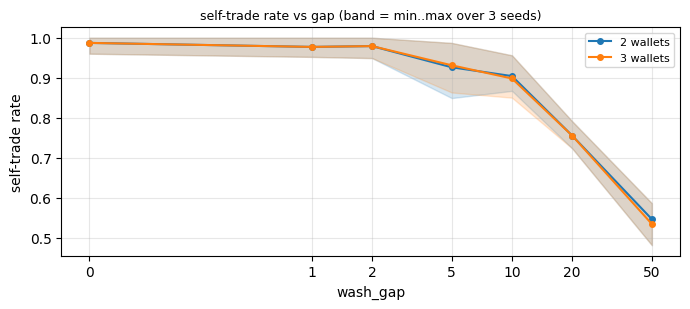

In [11]:
rob = (scan.groupby(["n_wallets", "gap"])
           .agg(self_mean=("self_trade_rate", "mean"), self_min=("self_trade_rate", "min"),
                self_max=("self_trade_rate", "max"),
                int_mean=("intercept_rate", "mean"), int_min=("intercept_rate", "min"),
                int_max=("intercept_rate", "max"))
           .round(3))
display(rob)

fig, ax = plt.subplots(figsize=(7, 3.2))
for n_w, c in ((2, "tab:blue"), (3, "tab:orange")):
    s = rob.loc[n_w]
    ax.plot(s.index, s["self_mean"], "o-", color=c, ms=4, label=f"{n_w} wallets")
    ax.fill_between(s.index, s["self_min"], s["self_max"], color=c, alpha=.18)
ax.set_xscale("symlog", linthresh=1); ax.set_xticks(GAPS); ax.set_xticklabels(GAPS)
ax.set_xlabel("wash_gap"); ax.set_ylabel("self-trade rate")
ax.set_title("self-trade rate vs gap (band = min..max over 3 seeds)", fontsize=9)
ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
### Summary

- **2 wallets are now covered**: an A↔B reciprocal edge; at gap=0 it self-trades ~99% of the time just like 3 wallets, and the net
  position returns to zero every 2 events. The market-level metrics of the two are almost identical; the difference is only in
  the **structure of the counterparty graph** (one reciprocal edge vs. a directed triangle), which is exactly what Part 2 has
  to tell apart.
- **The time gap is a parameter**: `wash_gap=0` is strictly equivalent to v1; as the gap grows, the self-trade rate falls
  monotonically, the intercept rate rises monotonically, and the wallet group's net position no longer returns strictly to
  zero. **The gap is the spillover knob that v1 lacked** (`wash_eps` is not, as verified in v1), and it carries no
  price-manipulation component: both legs are still anchored to the midpoint at posting time and do not deliberately push
  the price down or up.
- **The LOB is persisted**: book snapshots + top-5 levels + trade tape + wash events / per-leg fills + meta, all as CSV/JSON;
  the recorder is read-only and does not disturb the simulation's random path.

**TODO:** freeze the log schema (the three tables `wash_events` / `wash_fills` / `wash_orders` of v2 are the candidates; see
`washtrade/v3/export.py`) and define the pairing rule for the adjacency matrix B (see `detection/v1/pairing.py`). With
gap>0, "who traded with whom" is inherently unidentifiable inside a batch clear (a uniform-price clear carries no pairing
information), which is a direct constraint on how the pairing rule can be defined.
